In [1]:
from google.colab import drive
drive.mount('/content/drive')
! cp "/content/drive/MyDrive/detection.tar.gz" /content/mineapple.zip

Mounted at /content/drive


In [2]:
! mkdir -p /content/mineapple
!tar -xzf /content/mineapple.zip -C /content/mineapple

In [3]:
import numpy as np
from PIL import Image
mask_files = sorted(__import__('glob').glob('/content/mineapple/detection/train/masks/*'))
print("sample mask:", mask_files[0])

mask = np.array(Image.open(mask_files[0]))
print("Mask shape:",mask.shape)
print("Unique values:", np.unique(mask))

sample mask: /content/mineapple/detection/train/masks/20150919_174151_image1.png
Mask shape: (1280, 720)
Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95]


In [4]:
"""
mask_to_yolo.py — Convert MinneApple instance segmentation masks to YOLO bounding box labels.

Each mask is a single-channel image where each apple instance has a unique
non-zero integer pixel value (0 = background). For each unique value, we find
the tightest enclosing bounding box and write it as a normalized YOLO line.
"""

import os
import numpy as np
from PIL import Image
import glob

IMAGES_DIR = '/content/mineapple/detection/train/images'
MASKS_DIR = '/content/mineapple/detection/train/masks'
YOLO_LABELS_OUT = '/content/mineapple/detection/train/yolo_labels'

os.makedirs(YOLO_LABELS_OUT, exist_ok=True)

mask_files = sorted(glob.glob(os.path.join(MASKS_DIR, '*')))
print(f"Found {len(mask_files)} mask files")

skipped = 0
converted = 0

for mask_path in mask_files:
    base_name = os.path.splitext(os.path.basename(mask_path))[0]

    # find matching image (extension may differ from mask)
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(IMAGES_DIR, base_name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break
    if img_path is None:
        print(f"Warning: no matching image for {base_name}, skipping")
        skipped += 1
        continue

    with Image.open(img_path) as im:
        img_w, img_h = im.size

    mask = np.array(Image.open(mask_path))

    # handle masks that might have extra channels (RGB instead of single-channel)
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    instance_ids = np.unique(mask)
    instance_ids = instance_ids[instance_ids != 0]  # drop background (0)

    yolo_lines = []
    for inst_id in instance_ids:
        ys, xs = np.where(mask == inst_id)
        if len(xs) == 0:
            continue

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        # skip degenerate/tiny boxes (likely mask noise, not a real apple)
        if (x_max - x_min) < 2 or (y_max - y_min) < 2:
            continue

        x_center = ((x_min + x_max) / 2) / img_w
        y_center = ((y_min + y_max) / 2) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    label_path = os.path.join(YOLO_LABELS_OUT, base_name + '.txt')
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

    converted += 1

print(f"\nDone. Converted: {converted}, Skipped (no image match): {skipped}")
print(f"YOLO labels written to: {YOLO_LABELS_OUT}")

Found 670 mask files

Done. Converted: 670, Skipped (no image match): 0
YOLO labels written to: /content/mineapple/detection/train/yolo_labels


Image: /content/mineapple/detection/train/images/20150919_174151_image186.png
Label: /content/mineapple/detection/train/yolo_labels/20150919_174151_image186.txt
Number of apples in this image: 100


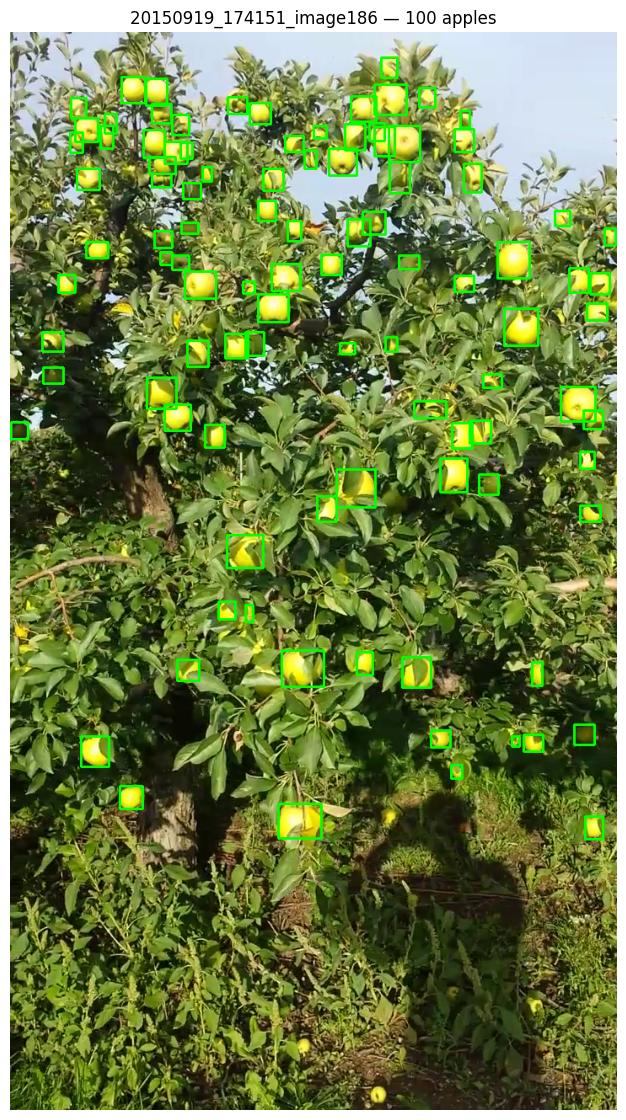

In [5]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

IMAGES_DIR = '/content/mineapple/detection/train/images'
YOLO_LABELS_DIR = '/content/mineapple/detection/train/yolo_labels'

# Grab the first image (sorted for consistency)
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, '*')))
first_image_path = image_files[20]
base_name = os.path.splitext(os.path.basename(first_image_path))[0]
label_path = os.path.join(YOLO_LABELS_DIR, base_name + '.txt')

print("Image:", first_image_path)
print("Label:", label_path)

img = cv2.imread(first_image_path)
h, w = img.shape[:2]

with open(label_path) as f:
    lines = f.readlines()

print(f"Number of apples in this image: {len(lines)}")

for line in lines:
    parts = line.strip().split()
    if len(parts) != 5:
        continue
    cls_id, xc, yc, bw, bh = map(float, parts)

    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)
    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"{base_name} — {len(lines)} apples")
plt.show()

In [6]:
import os
import shutil
import random
import glob

BASE_DIR = '/content/mineapple/detection'
TRAIN_IMAGES = f'{BASE_DIR}/train/images'
TRAIN_LABELS = f'{BASE_DIR}/train/yolo_labels'

VAL_IMAGES = f'{BASE_DIR}/val/images'
VAL_LABELS = f'{BASE_DIR}/val/labels'

os.makedirs(VAL_IMAGES, exist_ok=True)
os.makedirs(VAL_LABELS, exist_ok=True)

# Also rename train's yolo_labels -> labels for consistency (YOLO convention)
NEW_TRAIN_LABELS = f'{BASE_DIR}/train/labels'
if not os.path.exists(NEW_TRAIN_LABELS):
    shutil.copytree(TRAIN_LABELS, NEW_TRAIN_LABELS)

image_files = sorted([os.path.basename(f) for f in glob.glob(os.path.join(TRAIN_IMAGES, '*'))
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

random.seed(42)
random.shuffle(image_files)

val_ratio = 0.2
split_idx = int(len(image_files) * (1 - val_ratio))
val_files = image_files[split_idx:]   # last 20% moves to val

print(f"Total images: {len(image_files)} | Moving {len(val_files)} to val")

for img_name in val_files:
    base_name = os.path.splitext(img_name)[0]
    label_name = base_name + '.txt'

    # MOVE (not copy) so images aren't duplicated between train/val
    shutil.move(os.path.join(TRAIN_IMAGES, img_name), os.path.join(VAL_IMAGES, img_name))

    src_label = os.path.join(NEW_TRAIN_LABELS, label_name)
    if os.path.exists(src_label):
        shutil.move(src_label, os.path.join(VAL_LABELS, label_name))
    else:
        open(os.path.join(VAL_LABELS, label_name), 'w').close()

print("Done.")
print(f"Train remaining: {len(os.listdir(TRAIN_IMAGES))} images")
print(f"Val: {len(os.listdir(VAL_IMAGES))} images")

Total images: 670 | Moving 134 to val
Done.
Train remaining: 536 images
Val: 134 images


In [7]:
import yaml

yaml_content = {
    'path': '/content/mineapple/detection',
    'train': 'train/images',
    'val': 'val/images',
    'names': {0: 'apple'}
}

with open('/content/mineapple/detection/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print("data.yaml created")

data.yaml created


In [8]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.4 MB/s eta 0:00:00


In [19]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data = "/content/mineapple/detection/data.yaml",
    epochs = 200,
    imgsz = 350,
    batch = 16,
    patience = 20,
    device = 0,
    project = "apple_counter",
    name = "yolov8n_apple_mineapple_v2",
)

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mineapple/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=350, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_apple_mineapp

In [18]:
metric = model.val()
print("mAP@0.5:",metric.box.map50)
print("mAP@5:0.95:",metric.box.map)

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2020.5±1208.7 MB/s, size: 1835.8 KB)
val: Scanning /content/mineapple/detection/val/labels.cache... 134 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 134/134 26.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.3s/it 11.6s
                   all        134       5585      0.753      0.615      0.657      0.263
Speed: 1.7ms preprocess, 10.0ms inference, 0.0ms loss, 13.0ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@0.5: 0.6571399350456498
mAP@5:0.95: 0.2627020089815169



image 1/1 /content/mineapple/detection/test/images/dataset1_front_1381.png: 320x192 61 apples, 29.4ms
Speed: 3.6ms preprocess, 29.4ms inference, 6.5ms postprocess per image at shape (1, 3, 320, 192)
Count: 61


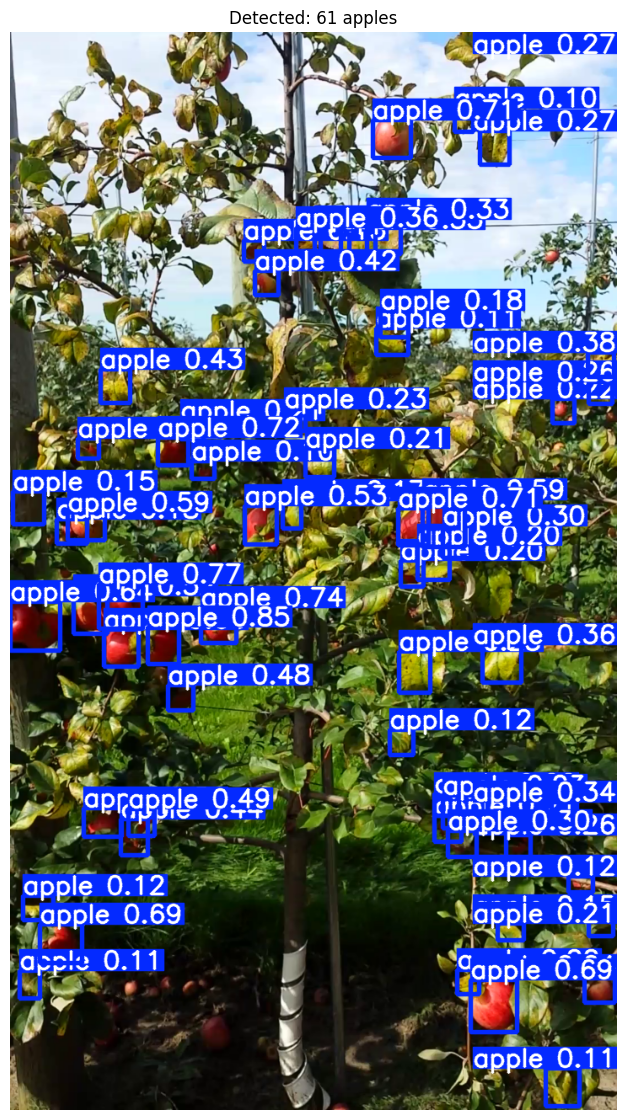

In [17]:
import matplotlib.pyplot as plt
import cv2

results = model('/content/mineapple/detection/test/images/dataset1_front_1381.png', conf=0.1, iou=0.3)
r = results[0]
print("Count:", len(r.boxes))

annotated = r.plot()  # returns BGR numpy array with boxes drawn

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))  # BGR -> RGB for correct colors
plt.axis('off')
plt.title(f"Detected: {len(r.boxes)} apples")
plt.show()

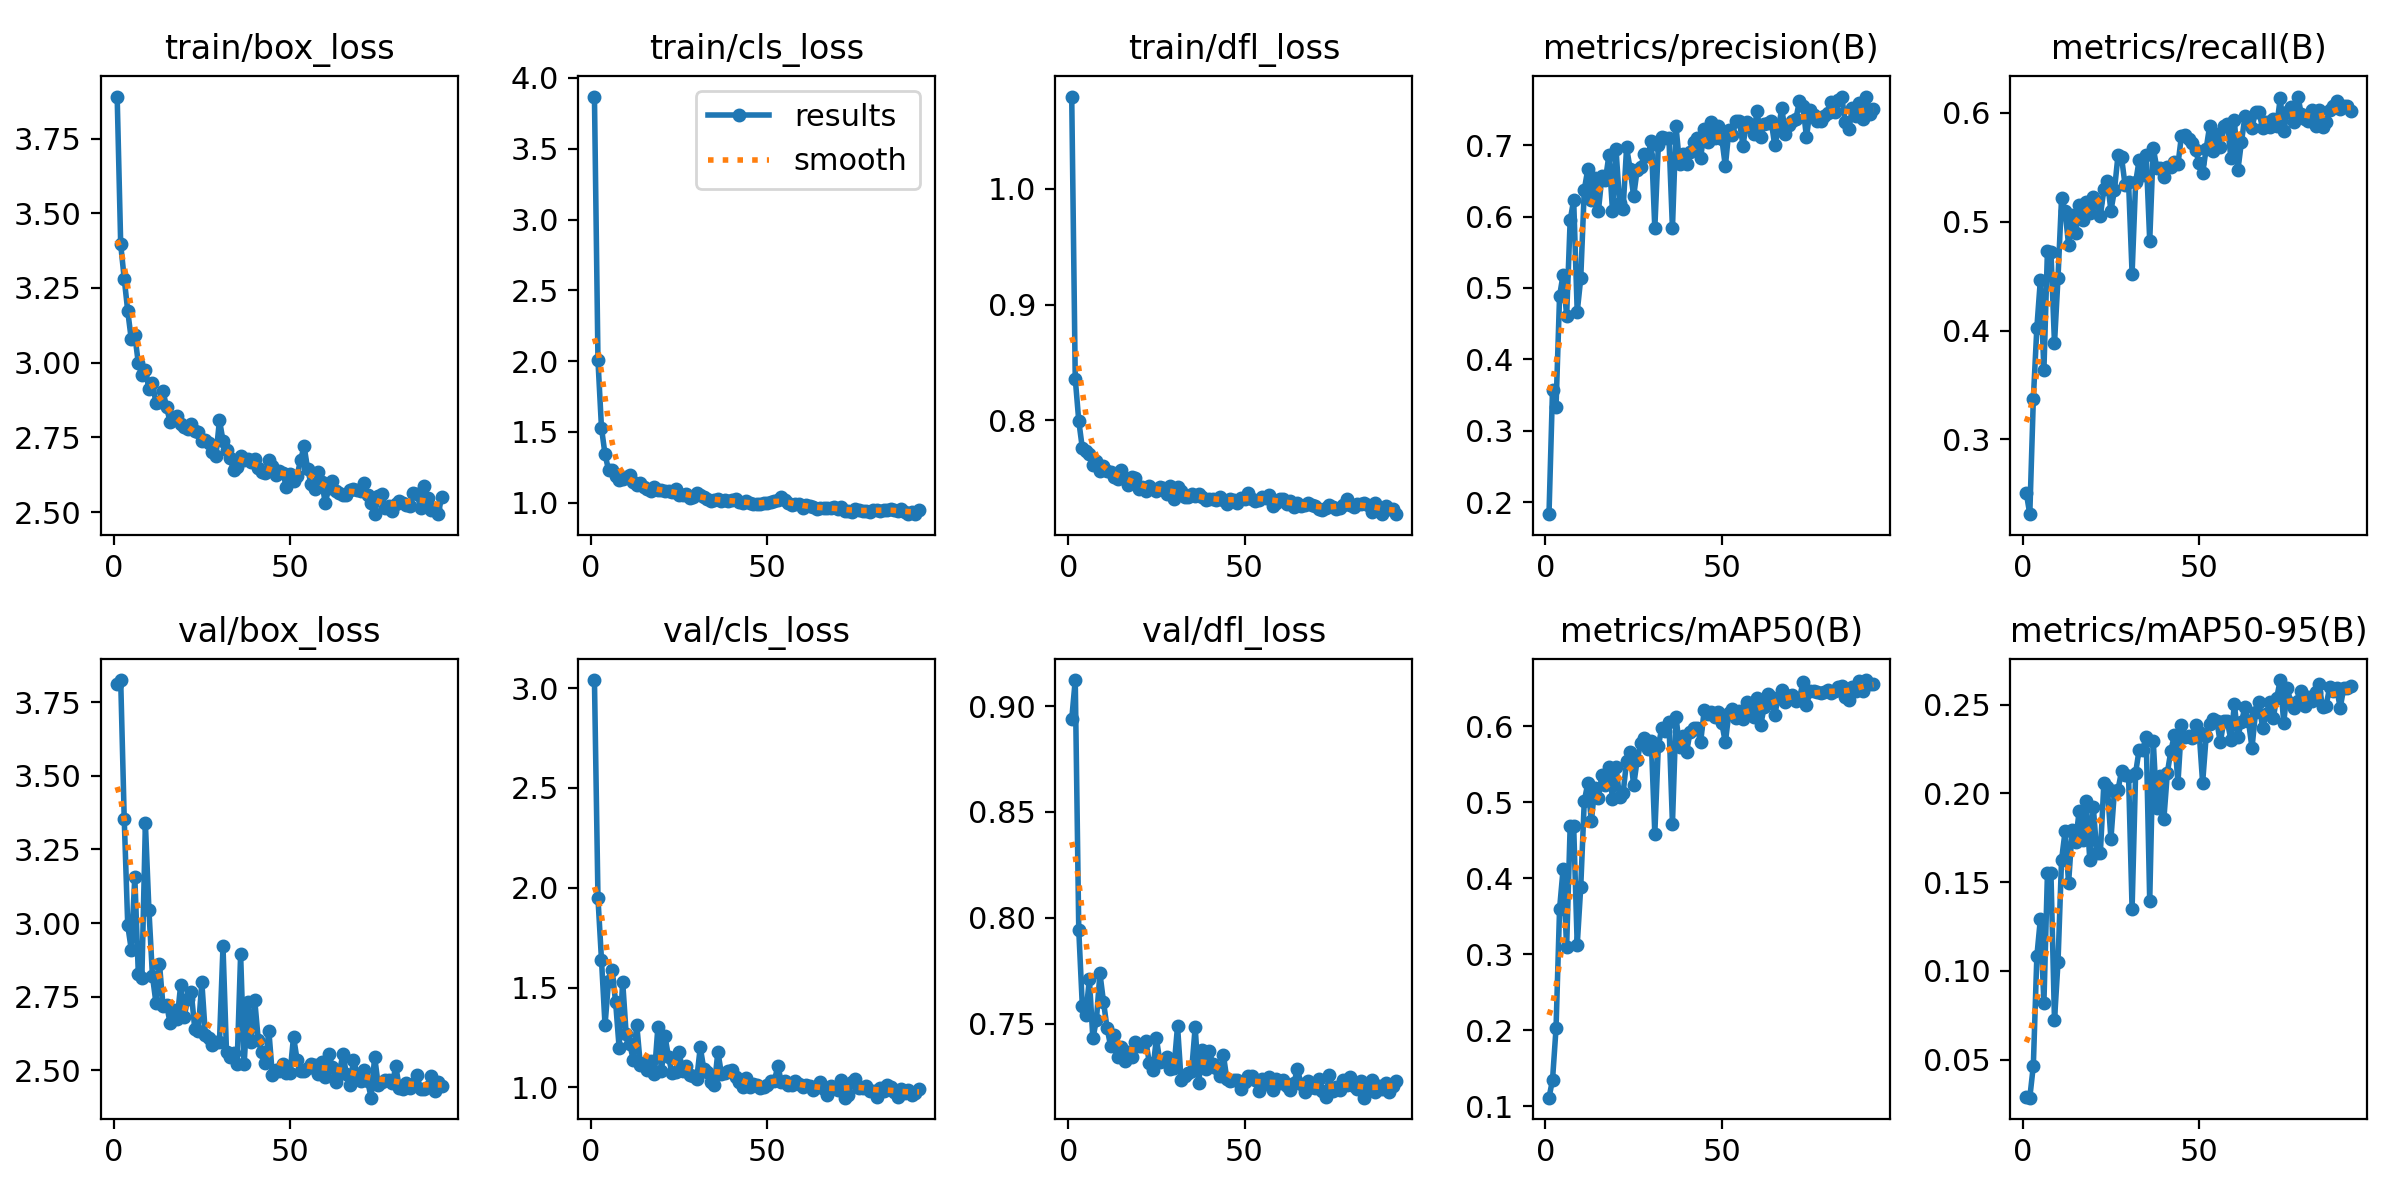

In [13]:
from IPython.display import Image as IPImage

IPImage('/content/runs/detect/apple_counter/yolov8n_apple_mineapple_v2/results.png')

In [20]:
from google.colab import files
files.download('/content/runs/detect/apple_counter/yolov8n_apple_mineapple_v2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>